In [12]:
from datetime import datetime as dt, timedelta
# import datetime as dt
import pandas as pd
import numpy as np
import requests
import yfinance as yf
import talib
from sqlalchemy import create_engine
import mysql.connector
import matplotlib.pyplot as plt

In [2]:

db_name = 'fint'
db_id = 'testuser'
db_pwd = 'test1234'
db_host = 'localhost'
db_url = f'mysql+mysqlconnector://{db_id}:{db_pwd}@{db_host}/{db_name}'

engine = create_engine(db_url)

def ToSQL(df: pd.DataFrame, engine: create_engine, table_name: str, if_exists: str = 'append'):
    """
    Pandas DataFrame을 SQL 데이터베이스 테이블에 저장합니다.
    트랜잭션을 안전하게 관리하여 오류를 방지합니다.

    Args:
        df (pd.DataFrame): 저장할 DataFrame
        engine (create_engine): SQLAlchemy 데이터베이스 엔진
        table_name (str): 데이터를 저장할 테이블 이름
        if_exists (str): 테이블 존재 시 처리 방법 ('fail', 'replace', 'append')
    """
    try:
        # with 구문을 사용하여 연결과 트랜잭션을 안전하게 관리
        with engine.connect() as conn:
            with conn.begin() as transaction:
                # 데이터 삽입
                df.to_sql(name=table_name, con=conn, if_exists=if_exists, index=False, chunksize=10000)
        
        print(f"Success: '{table_name}' 테이블에 데이터가 성공적으로 저장되었습니다.")
    
    except Exception as e:
        print(f"Error... : {e}")
        # with conn.begin()이 오류를 감지하면 자동으로 롤백을 수행합니다.
        # 따라서 명시적인 transaction.rollback() 호출은 필요하지 않습니다.


def FromSQL(engine: create_engine, table_name: str, query: str = None, params: dict = None) -> pd.DataFrame:
    """
    SQL 데이터베이스에서 데이터를 조회하여 Pandas DataFrame으로 반환합니다.
    
    Args:
        engine (create_engine): SQLAlchemy 데이터베이스 엔진
        table_name (str): 데이터를 조회할 테이블 이름
    """
    try:
        if query:
            # 쿼리가 제공되면 해당 쿼리를 실행합니다.
            df = pd.read_sql(sql=query, con=engine, params=params)
        else:
            # 쿼리가 없으면 전체 테이블을 조회합니다.
            df = pd.read_sql_table(table_name=table_name, con=engine)
            
        print(f"Success: '{table_name}' 테이블에서 데이터를 성공적으로 로드했습니다.")
        return df
        
    except Exception as e:
        print(f"Error... : {e}")
        return pd.DataFrame() # 오류 발생 시 빈 DataFrame 반환

In [ ]:
# 2-3분 소요
report_df = FromSQL(engine, 'report')
report_df.head()

Success: 'report' 테이블에서 데이터를 성공적으로 로드했습니다.


,report_id,report_date,stock_id,open,close,high,low,volume,rsi,macd,macd_signal,macd_hist,atr,stoch_k,stoch_d,obv
0,1,1999-11-18,1,27.299923,26.399927,29.999919,23.999933,62546380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62546380.0
1,2,1999-11-19,1,25.762430,24.224936,25.799931,23.887436,15234146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47312234.0
2,3,1999-11-22,1,24.787431,26.399927,26.399927,24.037433,6577870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53890104.0
3,4,1999-11-23,1,25.499931,23.999935,26.174930,23.999935,5975611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47914493.0
4,5,1999-11-24,1,24.074945,24.637444,25.162443,23.999944,4843231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52757724.0


In [3]:
stock_df = FromSQL(engine, 'stock')
stock_df.head()

Success: 'stock' 테이블에서 데이터를 성공적으로 로드했습니다.


,stock_id,ticker,name,sector,industry,city,ipo,image,reg_date
0,1,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,Santa Clara,1999-11-18,None,2025-09-11
1,2,AAL,American Airlines Group Inc.,Industrials,Airlines,Fort Worth,2005-09-27,None,2025-09-11
2,3,AAP,"Advance Auto Parts, Inc.",Consumer Cyclical,Auto Parts,Raleigh,2001-11-29,None,2025-09-11
3,4,AAPL,Apple Inc.,Technology,Consumer Electronics,Cupertino,1980-12-12,None,2025-09-11
4,5,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General,North Chicago,2013-01-02,None,2025-09-11


# Utility

In [5]:
def getStockId(ticker):
    return stock_df[stock_df['ticker'] == ticker]['stock_id'].values[0]

def getStockData(ticker):
    return report_df[report_df['stock_id'] == getStockId(ticker)].copy()

# ARIMA

In [21]:
report_df[report_df['stock_id'] == getStockId('NVDA')].columns

Index(['report_id', 'report_date', 'stock_id', 'open', 'close', 'high', 'low',
       'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k',
       'stoch_d', 'obv'],
      dtype='object')

In [26]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.instance().ast_node_interactivity = "all"

# 출력 줄 수 제한 해제
InteractiveShell.instance().display_truncate_limit = 0


In [28]:
from statsmodels.tsa.arima.model import ARIMA

# NVDA의 종가(close) 데이터 추출
nvda_df = report_df[report_df['stock_id'] == getStockId('NVDA')].copy()
nvda_series = nvda_df.set_index('report_date')['close']

# 데이터 분할
# 2020-01-01부터 2020-03-29까지를 학습 데이터로 사용
train_data = nvda_series.loc[:'2020-03-29']
# 2020-03-30 이후를 테스트 데이터로 사용
test_data = nvda_series.loc['2020-03-30':]

# ARIMA 모델 정의 및 학습
# (p, d, q) = (1, 1, 1)은 모델의 일반적인 파라미터 조합입니다.
# d=1은 비정상성을 제거하기 위한 차분(differencing) 횟수를 의미합니다.
model = ARIMA(train_data, order=(1, 1, 1))
model_fit = model.fit()

# 모델 요약 정보 출력
print(model_fit.summary())

# 5일 뒤 예측
# .forecast(steps=5)를 사용해 재귀적 예측을 수행합니다.
forecast_results = model_fit.forecast(steps=5)

print("\n------------------------------")
print("5일 뒤 예측값:")
print(forecast_results)
print("------------------------------")

c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 5330
Model:                 ARIMA(1, 1, 1)   Log Likelihood                7507.709
Date:                Mon, 15 Sep 2025   AIC                         -15009.418
Time:                        14:44:18   BIC                         -14989.676
Sample:                             0   HQIC                        -15002.521
                               - 5330                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4184      0.020    -20.501      0.000      -0.458      -0.378
ma.L1          0.2879      0.022     13.269      0.000       0.245       0.330
sigma2         0.0035   1.17e-05    299.389      0.0

c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: N

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'ARIMA Model Forecasting vs Actual Data')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Close Price')

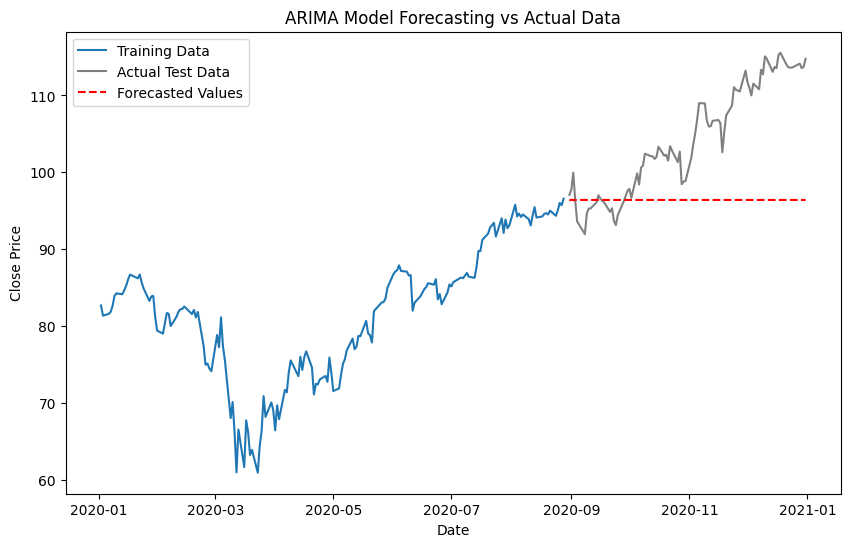

In [32]:
nvda_df = report_df[report_df['stock_id'] == 1].copy()
nvda_series = nvda_df.set_index('report_date')['close']

train_data = nvda_series.loc['2020-01-01':'2020-08-29']
test_data = nvda_series.loc['2020-08-30':'2021-01-01']

# ARIMA 모델 학습 (이전 예제와 동일)
model = ARIMA(train_data, order=(1, 1, 1))
model_fit = model.fit()

# 예측 수행
forecast_results = model_fit.forecast(steps=len(test_data))

# 예측 결과를 Pandas Series로 변환하여 인덱스 설정
forecast_series = pd.Series(forecast_results.values, index=test_data.index)

# 그래프 그리기
plt.figure(figsize=(10, 6))

# 학습 데이터
plt.plot(train_data, label='Training Data')

# 실제 테스트 데이터
plt.plot(test_data, color='gray', label='Actual Test Data')

# 예측값
plt.plot(forecast_series, color='red', linestyle='--', label='Forecasted Values')

plt.title('ARIMA Model Forecasting vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# ML

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import classification_report

import seaborn as sns

In [ ]:
seed = 51

# model set
dt_model = DecisionTreeRegressor(random_state=seed)
rf_model = RandomForestRegressor(n_estimators=200, random_state=seed)

# function
def split(X, y):
  return train_test_split(X, y, test_size=0.2, random_state=seed)

def train(model, X_train, y_train):
  model.fit(X_train, y_train)
  print('model', model.score(X_train, y_train))
  return model

def predict(model, X_test, y_test):
  pred = model.predict(X_test)
  print('mse', mean_squared_error(y_test, pred))
  print('rmse', ((y_test-pred)**2).mean()**0.5)

def exec(model, X, y):
  X_train, X_test, y_train, y_test = split(X, y)
  trained_model = train(model, X_train, y_train)
  predict(trained_model, X_test, y_test)
  print(classification_report(y_test, model.predict(X_test)))
  print(model.score(X_test, y_test))


In [ ]:
def predict_recursive(model, initial_X, steps):
    """
    재귀적 예측을 수행하는 함수
    :param model: 학습된 모델
    :param initial_X: 예측을 시작할 초기 입력 데이터 (마지막 날 데이터)
    :param steps: 예측할 일수
    :return: 예측값 리스트
    """
    predicted_values = []
    current_X = initial_X.copy()

    for _ in range(steps):
        # 1. 현재 입력 데이터로 다음 날 가격 예측
        next_day_pred = model.predict(current_X)
        predicted_values.append(next_day_pred[0])
        
        # 2. 다음 예측을 위한 입력 데이터 업데이트
        # 현재의 예측값을 다음 예측의 'close' 값으로 사용
        current_X_copy = current_X.copy()
        current_X_copy['close'] = next_day_pred[0]
        # 다른 기술 지표들도 업데이트해야 하지만, 예제에서는 생략
        current_X = current_X_copy
        
    return predicted_values


In [ ]:
def split(X, y, start_date, today, end_date):
    # train: start_date <= 날짜 <= today
    train_mask = (X.index >= start_date) & (X.index <= today)
    X_train = X[train_mask]
    y_train = y[train_mask]
    
    # test: today < 날짜 <= end_date
    test_mask = (X.index > today) & (X.index <= end_date)
    X_test = X[test_mask]
    y_test = y[test_mask]
    
    return X_train, X_test, y_train, y_test

def train(model, X_train, y_train):
    model.fit(X_train, y_train)
    print('모델 학습 완료')
    return model

def predict_recursive(model, initial_X, steps):
    """
    재귀적 예측을 수행하는 함수
    :param model: 학습된 모델
    :param initial_X: 예측을 시작할 초기 입력 데이터 (마지막 날 데이터)
    :param steps: 예측할 일수
    :return: 예측값 리스트
    """
    predicted_values = []
    current_X = initial_X.copy()

    for _ in range(steps):
        # 1. 현재 입력 데이터로 다음 날 가격 예측
        next_day_pred = model.predict(current_X)
        predicted_values.append(next_day_pred[0])
        
        # 2. 다음 예측을 위한 입력 데이터 업데이트
        # 현재의 예측값을 다음 예측의 'close' 값으로 사용
        current_X_copy = current_X.copy()
        current_X_copy['close'] = next_day_pred[0]
        # 다른 기술 지표들도 업데이트해야 하지만, 예제에서는 생략
        current_X = current_X_copy
        
    return predicted_values

def exec(model, ticker, today, train_days, predict_days):
    stock_df = getStockData(ticker)
    stock_df.set_index('report_date', inplace=True)
    stock_df['target'] = stock_df['close'].shift(-1)
    stock_df.dropna(inplace=True)

    X = stock_df.drop(columns=['target'])
    y = stock_df['target']

    start_date = today - timedelta(days=train_days)
    end_date = today + timedelta(days=predict_days)

    # dates = pd.date_range(start=start_date, end=end_date)
    # print(dates)

    X_train, X_test, y_train, y_test = split(X, y, start_date, today, end_date)

    # print('X_train', X_train.head())
    # print('X_test', X_test.head())
    # print('y_train', y_train.head())
    # print('y_test', y_test.head())

    # 모델 학습
    model = train(model, X_train, y_train)

    # 재귀적 예측
    # predicted_values = predict_recursive(model, X_test, y_test)
    initial_X_for_predict = X_test.iloc[[0]] 
    predicted_5_days = predict_recursive(model, initial_X_for_predict, steps=5)

    # 예측 결과 출력
    print("5일간의 재귀적 예측값:", predicted_5_days)

    return predicted_5_days


In [31]:
import datetime as dt

seed = 51

# model set
dt_model = DecisionTreeRegressor(random_state=seed)
rf_model = RandomForestRegressor(n_estimators=200, random_state=seed)

exec(rf_model, 'NVDA', dt.datetime(2020, 1, 1), 90, 5)

모델 학습 완료
5일간의 재귀적 예측값: [np.float64(5.904974617958069), np.float64(5.905522246360778), np.float64(5.905143914222717), np.float64(5.905143914222717), np.float64(5.905143914222717)]


[np.float64(5.904974617958069),
 np.float64(5.905522246360778),
 np.float64(5.905143914222717),
 np.float64(5.905143914222717),
 np.float64(5.905143914222717)]

In [34]:
exec(rf_model, 'NVDA', dt.datetime(2020, 1, 1), 90, 5)

모델 학습 완료
5일간의 재귀적 예측값: [np.float64(5.904974617958069), np.float64(5.905522246360778), np.float64(5.905143914222717), np.float64(5.905143914222717), np.float64(5.905143914222717)]


[np.float64(5.904974617958069),
 np.float64(5.905522246360778),
 np.float64(5.905143914222717),
 np.float64(5.905143914222717),
 np.float64(5.905143914222717)]

In [33]:
exec(dt_model, 'NVDA', dt.datetime(2020, 1, 1), 90, 5)

모델 학습 완료
5일간의 재귀적 예측값: [np.float64(5.944279670715332), np.float64(5.944279670715332), np.float64(5.944279670715332), np.float64(5.944279670715332), np.float64(5.944279670715332)]


[np.float64(5.944279670715332),
 np.float64(5.944279670715332),
 np.float64(5.944279670715332),
 np.float64(5.944279670715332),
 np.float64(5.944279670715332)]

In [ ]:
tsla_df = getStockData('TSLA')

tsla_df.set_index('report_date', inplace=True)
tsla_df['target'] = tsla_df['close'].shift(-1)
tsla_df.dropna(inplace=True)

X = tsla_df.drop(columns=['target'])
y = tsla_df['target']

start_date = '2020-01-01'
end_date = '2021-01-01'

,report_id,stock_id,open,close,high,low,volume,rsi,macd,macd_signal,macd_hist,atr,stoch_k,stoch_d,obv
report_date,,,,,,,,,,,,,,,
2010-06-29,5051580,635,1.266667,1.592667,1.666667,1.169333,281494500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,281494500.0
2010-06-30,5051581,635,1.719333,1.588667,2.028000,1.553333,257806500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23688000.0
2010-07-01,5051582,635,1.666667,1.464000,1.728000,1.351333,123282000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-99594000.0
2010-07-02,5051583,635,1.533333,1.280000,1.540000,1.247333,77097000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-176691000.0
2010-07-06,5051584,635,1.333333,1.074000,1.333333,1.055333,103003500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-279694500.0


# ML2

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import timedelta
import talib as ta


def calculate_indicators(df):
    # TA-Lib는 컬럼명을 구분하므로 대문자 컬럼명으로 변경
    df.columns = df.columns.str.lower()
    df_temp = df.copy()

    # 기술 지표 계산
    df_temp['rsi'] = ta.RSI(df_temp['close'].values, timeperiod=14)
    df_temp['macd'], df_temp['macd_signal'], df_temp['macd_hist'] = ta.MACD(
        df_temp['close'].values, fastperiod=12, slowperiod=26, signalperiod=9)
    df_temp['atr'] = ta.ATR(df_temp['high'].values, df_temp['low'].values, df_temp['close'].values, timeperiod=14)
    df_temp['stoch_k'], df_temp['stoch_d'] = ta.STOCH(
        df_temp['high'].values, df_temp['low'].values, df_temp['close'].values,
        fastk_period=5, slowk_period=3, slowd_period=3)
    df_temp['obv'] = ta.OBV(df_temp['close'].values, df_temp['volume'].values)

    # 지표 계산으로 인해 발생한 NaN 값 행 제거
    return df_temp.dropna()

def split(X, y, start_date, today, end_date):
    # Python date 객체를 Pandas datetime 객체로 변환
    start_date_pd = pd.to_datetime(start_date)
    today_pd = pd.to_datetime(today)
    end_date_pd = pd.to_datetime(end_date)
    
    # train: start_date <= 날짜 <= today
    train_mask = (X.index >= start_date_pd) & (X.index <= today_pd)
    X_train = X[train_mask]
    y_train = y[train_mask]
    
    # test: today < 날짜 <= end_date
    test_mask = (X.index > today_pd) & (X.index <= end_date_pd)
    X_test = X[test_mask]
    y_test = y[test_mask]
    
    return X_train, X_test, y_train, y_test

def train(model, X_train, y_train):
    """모델 학습"""
    model.fit(X_train, y_train)
    print('모델 학습 완료')
    return model

def predict_recursive(model, initial_X_df, steps, df_for_recalc):
    """
    재귀적 예측을 수행하는 함수
    :param model: 학습된 모델
    :param initial_X_df: 예측을 시작할 초기 입력 데이터 (학습 데이터 마지막 날 데이터)
    :param steps: 예측할 일수
    :param df_for_recalc: 지표 재계산을 위한 전체 데이터프레임의 일부 (최근 데이터)
    :return: 예측값 리스트
    """
    predicted_values = []
    current_data_point = initial_X_df.copy()
    current_full_df = df_for_recalc.copy()

    for i in range(steps):
        # 1. 현재 데이터 포인트로 다음 날 가격 예측
        next_day_pred = model.predict(current_data_point)[0]
        predicted_values.append(next_day_pred)
        
        # 2. 다음 예측을 위한 입력 데이터 업데이트
        next_day_index = current_full_df.index[-1] + pd.Timedelta(days=1)
        
        new_row_data = current_data_point.iloc[0].to_dict()
        new_row_data['close'] = next_day_pred
        new_row_data['open'] = next_day_pred
        new_row_data['high'] = next_day_pred * 1.01
        new_row_data['low'] = next_day_pred * 0.99
        new_row_data['volume'] = new_row_data['volume']
        
        new_row_df = pd.DataFrame([new_row_data], index=[next_day_index])
        current_full_df = pd.concat([current_full_df, new_row_df])
        
        updated_data_df = calculate_indicators(current_full_df)
        
        current_data_point = updated_data_df.iloc[[-1]].copy()
        
    return predicted_values

def exec_model(model, ticker, today, train_days, predict_steps):
    """
    모델 학습, 재귀적 예측, 성능 평가를 수행하는 메인 함수
    """
    
    end_date = today + timedelta(days=predict_steps)
    start_date = today - timedelta(days=train_days)
    
    stock_df = getStockData(ticker)
    stock_df.set_index('report_date', inplace=True)
    stock_df['target'] = stock_df['close'].shift(-1)
    stock_df.dropna(inplace=True)
    
    X = stock_df.drop(columns=['target'])
    y = stock_df['target']

    X_train, X_test, y_train, y_test = split(X, y, start_date, today, end_date)
    
    print(f"학습 데이터 기간: {X_train.index[0].date()} ~ {X_train.index[-1].date()}")
    print(f"테스트 데이터 기간: {X_test.index[0].date()} ~ {X_test.index[-1].date()}")
    print("-" * 50)
    
    # 5. 모델 학습
    trained_model = train(model, X_train, y_train)

    # 6. 재귀적 예측 실행
    initial_X_for_predict = X_train.iloc[[-1]] # 학습 데이터의 마지막 행
    
    # 지표 재계산을 위해 충분한 과거 데이터(예: 50일)를 전달
    df_for_recalc = X_train.iloc[-50:].copy() 
    
    predicted_values = predict_recursive(trained_model, initial_X_for_predict, steps=predict_steps, df_for_recalc=df_for_recalc)
    
    # 7. 성능 평가
    actual_values = y_test.head(predict_steps).values
    
    print("\n재귀적 예측 결과:")
    for i, (pred, actual) in enumerate(zip(predicted_values, actual_values)):
        print(f"예측일: D+{i+1} | 예측값: {pred:.2f} | 실제값: {actual:.2f}")

    if len(predicted_values) == len(actual_values):
        mse = mean_squared_error(actual_values, predicted_values)
        rmse = np.sqrt(mse)
        print(f"\n성능 평가 (첫 {predict_steps}일):")
        print(f"MSE: {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
    
    return predicted_values

# --- 실행부 ---
seed = 51

# model set
rf_model = RandomForestRegressor(n_estimators=100, random_state=seed)

# 메인 함수 실행
today_date = dt.date(2025, 9, 7)
predicted_prices = exec_model(rf_model, 'NVDA', today_date, train_days=500, predict_steps=5)

학습 데이터 기간: 2024-04-25 ~ 2025-09-05
테스트 데이터 기간: 2025-09-08 ~ 2025-09-11
--------------------------------------------------
모델 학습 완료

재귀적 예측 결과:
예측일: D+1 | 예측값: 168.65 | 실제값: 170.75
예측일: D+2 | 예측값: 168.16 | 실제값: 177.32
예측일: D+3 | 예측값: 168.11 | 실제값: 177.17
예측일: D+4 | 예측값: 168.40 | 실제값: 177.82


c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Aaron\SHDS_ESC\StockSimulator\StockSimulator-Data\dataEnv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [50]:
nvda_df = getStockData('NVDA')
nvda_df[nvda_df['report_date'] > '2025-09-01']

,report_id,report_date,stock_id,open,close,high,low,volume,rsi,macd,macd_signal,macd_hist,atr,stoch_k,stoch_d,obv
3800107,3800108,2025-09-02,475,169.990416,170.770370,172.370286,167.210574,231164900,41.253445,1.320739,2.830311,-1.509572,5.093979,42.509898,64.359678,1.641024e+11
3800108,3800109,2025-09-03,475,171.050360,170.610382,172.400290,168.870490,164424900,41.029780,0.677406,2.399730,-1.722324,4.982252,24.893615,44.402885,1.639380e+11
3800109,3800110,2025-09-04,475,170.560395,171.650330,171.850315,169.400456,141670100,43.186038,0.248610,1.969506,-1.720896,4.801367,22.028999,29.810837,1.640797e+11
3800110,3800111,2025-09-05,475,168.020527,167.010590,169.020471,164.060759,224441400,36.732658,-0.460297,1.483545,-1.943842,5.000524,19.970034,22.297550,1.638552e+11
3800111,3800112,2025-09-08,475,167.540555,168.300507,170.950366,167.340569,163769100,39.442026,-0.907563,1.005324,-1.912887,4.924756,20.328071,20.775702,1.640190e+11
3800112,3800113,2025-09-09,475,169.080462,170.750366,170.970355,166.730604,157548400,44.319094,-1.052212,0.593816,-1.646029,4.875827,22.679700,20.992602,1.641766e+11
3800113,3800114,2025-09-10,475,176.630044,177.320007,179.279888,175.460112,226852000,54.825732,-0.629477,0.349158,-0.978635,5.136806,39.526114,27.511295,1.644034e+11
3800114,3800115,2025-09-11,475,179.679993,177.169998,180.279999,176.479996,151159300,54.572515,-0.303067,0.218713,-0.521779,5.041320,59.539773,40.581863,1.642523e+11
3800115,3800116,2025-09-12,475,177.770004,177.820007,178.600006,176.449997,124618700,55.530927,0.007974,0.176565,-0.168591,4.834798,76.886046,58.650645,1.643769e+11


In [52]:
nvda_df.columns

Index(['report_id', 'report_date', 'stock_id', 'open', 'close', 'high', 'low',
       'volume', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'stoch_k',
       'stoch_d', 'obv'],
      dtype='object')

In [53]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from datetime import timedelta
import talib as ta
import warnings
warnings.filterwarnings('ignore')

class StockPredictor:
    def __init__(self, model=None, use_scaler=True, random_state=42):
        self.model = model if model else RandomForestRegressor(
            n_estimators=200, 
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=random_state
        )
        self.use_scaler = use_scaler
        self.scaler = StandardScaler() if use_scaler else None
        self.feature_columns = None
        
    def prepare_features(self, df):
        """피처 준비 및 엔지니어링"""
        df_temp = df.copy()
        
        # 기존 지표가 있는지 확인
        has_indicators = all(col in df_temp.columns for col in ['rsi', 'macd', 'atr'])
        
        if not has_indicators:
            print("기술 지표 계산 중...")
            df_temp = self.calculate_indicators(df_temp)
        
        # 추가 피처 엔지니어링
        df_temp = self.add_engineered_features(df_temp)
        
        # 타겟 변수 생성 (다음날 수익률)
        df_temp['target'] = (df_temp['close'].shift(-1) / df_temp['close'] - 1) * 100
        
        # NaN 제거
        df_temp = df_temp.dropna()
        
        return df_temp
    
    def calculate_indicators(self, df):
        """기술 지표 계산"""
        df.columns = df.columns.str.lower()
        df_temp = df.copy()
        
        # 기본 지표들
        df_temp['rsi'] = ta.RSI(df_temp['close'].values, timeperiod=14)
        df_temp['macd'], df_temp['macd_signal'], df_temp['macd_hist'] = ta.MACD(
            df_temp['close'].values, fastperiod=12, slowperiod=26, signalperiod=9)
        df_temp['atr'] = ta.ATR(df_temp['high'].values, df_temp['low'].values, 
                               df_temp['close'].values, timeperiod=14)
        df_temp['stoch_k'], df_temp['stoch_d'] = ta.STOCH(
            df_temp['high'].values, df_temp['low'].values, df_temp['close'].values,
            fastk_period=5, slowk_period=3, slowd_period=3)
        df_temp['obv'] = ta.OBV(df_temp['close'].values, df_temp['volume'].values)
        
        return df_temp
    
    def add_engineered_features(self, df):
        """추가 피처 엔지니어링"""
        df_temp = df.copy()
        
        # 이동평균
        for period in [5, 10, 20, 50]:
            df_temp[f'sma_{period}'] = df_temp['close'].rolling(period).mean()
            df_temp[f'price_to_sma_{period}'] = df_temp['close'] / df_temp[f'sma_{period}']
        
        # 볼린저 밴드
        sma_20 = df_temp['close'].rolling(20).mean()
        std_20 = df_temp['close'].rolling(20).std()
        df_temp['bb_upper'] = sma_20 + (std_20 * 2)
        df_temp['bb_lower'] = sma_20 - (std_20 * 2)
        df_temp['bb_position'] = (df_temp['close'] - df_temp['bb_lower']) / (df_temp['bb_upper'] - df_temp['bb_lower'])
        
        # 가격 변화율
        for period in [1, 3, 5, 10]:
            df_temp[f'return_{period}d'] = df_temp['close'].pct_change(period) * 100
        
        # 변동성
        df_temp['volatility_10d'] = df_temp['close'].pct_change().rolling(10).std() * 100
        df_temp['volatility_20d'] = df_temp['close'].pct_change().rolling(20).std() * 100
        
        # 거래량 지표
        df_temp['volume_sma_10'] = df_temp['volume'].rolling(10).mean()
        df_temp['volume_ratio'] = df_temp['volume'] / df_temp['volume_sma_10']
        
        return df_temp
    
    def get_feature_columns(self, df):
        """피처 컬럼 선택"""
        # 메타데이터 컬럼 제외
        exclude_cols = ['report_id', 'report_date', 'stock_id', 'target']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        return feature_cols
    
    def time_series_split_validate(self, X, y, n_splits=5):
        """시계열 교차검증"""
        tscv = TimeSeriesSplit(n_splits=n_splits)
        cv_scores = []
        
        for train_idx, val_idx in tscv.split(X):
            X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
            
            # 스케일링
            if self.use_scaler:
                X_train_scaled = self.scaler.fit_transform(X_train_cv)
                X_val_scaled = self.scaler.transform(X_val_cv)
            else:
                X_train_scaled, X_val_scaled = X_train_cv, X_val_cv
            
            # 모델 학습 및 예측
            self.model.fit(X_train_scaled, y_train_cv)
            pred = self.model.predict(X_val_scaled)
            
            mse = mean_squared_error(y_val_cv, pred)
            cv_scores.append(mse)
        
        return np.mean(cv_scores), np.std(cv_scores)
    
    def split_data(self, df, train_ratio=0.8):
        """데이터 분할"""
        split_idx = int(len(df) * train_ratio)
        train_df = df.iloc[:split_idx]
        test_df = df.iloc[split_idx:]
        return train_df, test_df
    
    def train(self, X_train, y_train):
        """모델 학습"""
        # 피처 컬럼 저장
        self.feature_columns = X_train.columns.tolist()
        
        # 교차검증
        cv_mean, cv_std = self.time_series_split_validate(X_train, y_train)
        print(f"교차검증 MSE: {cv_mean:.4f} ± {cv_std:.4f}")
        
        # 스케일링
        if self.use_scaler:
            X_train_scaled = self.scaler.fit_transform(X_train)
        else:
            X_train_scaled = X_train
        
        # 최종 모델 학습
        self.model.fit(X_train_scaled, y_train)
        print("모델 학습 완료")
        
        return self
    
    def predict_next_returns(self, X_last, steps=5):
        """수익률 기반 예측"""
        if self.feature_columns is None:
            raise ValueError("모델이 학습되지 않았습니다.")
        
        predictions = []
        current_features = X_last.copy()
        
        for step in range(steps):
            # 현재 피처로 수익률 예측
            if self.use_scaler:
                features_scaled = self.scaler.transform(current_features[self.feature_columns])
            else:
                features_scaled = current_features[self.feature_columns]
            
            return_pred = self.model.predict(features_scaled)[0]
            predictions.append(return_pred)
            
            # 다음 스텝을 위한 피처 업데이트 (간단한 방식)
            # 실제로는 더 정교한 업데이트 방식이 필요
            current_features = current_features.copy()
            
        return predictions
    
    def convert_returns_to_prices(self, initial_price, return_predictions):
        """수익률을 가격으로 변환"""
        prices = [initial_price]
        for return_pct in return_predictions:
            next_price = prices[-1] * (1 + return_pct / 100)
            prices.append(next_price)
        return prices[1:]  # 초기 가격 제외
    
    def evaluate_model(self, y_true, y_pred):
        """모델 성능 평가"""
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        
        # 방향성 정확도
        direction_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
        
        metrics = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'Direction_Accuracy': direction_accuracy
        }
        
        return metrics


def exec_improved_model(model_class, ticker, today, train_days, predict_steps):
    """개선된 메인 실행 함수"""
    
    # 데이터 로드 (getStockData 함수는 별도 구현 필요)
    stock_df = getStockData(ticker)
    stock_df.set_index('report_date', inplace=True)
    
    # 모델 초기화
    predictor = model_class()
    
    # 피처 준비
    prepared_df = predictor.prepare_features(stock_df)
    
    # 날짜 필터링
    end_date = today + timedelta(days=predict_steps)
    start_date = today - timedelta(days=train_days)
    
    date_mask = (prepared_df.index >= pd.to_datetime(start_date)) & \
                (prepared_df.index <= pd.to_datetime(end_date))
    filtered_df = prepared_df[date_mask]
    
    # 훈련/테스트 분할
    train_df, test_df = predictor.split_data(filtered_df)
    
    # 피처와 타겟 분리
    feature_cols = predictor.get_feature_columns(train_df)
    X_train = train_df[feature_cols]
    y_train = train_df['target']
    X_test = test_df[feature_cols]
    y_test = test_df['target']
    
    print(f"학습 데이터: {len(X_train)}개, 테스트 데이터: {len(X_test)}개")
    print(f"피처 수: {len(feature_cols)}")
    print("-" * 50)
    
    # 모델 학습
    predictor.train(X_train, y_train)
    
    # 예측
    if len(X_test) > 0:
        # 테스트 데이터로 평가
        if predictor.use_scaler:
            X_test_scaled = predictor.scaler.transform(X_test)
        else:
            X_test_scaled = X_test
        
        test_pred = predictor.model.predict(X_test_scaled)
        
        # 성능 평가
        metrics = predictor.evaluate_model(y_test.values, test_pred)
        
        print("\n모델 성능:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
    
    # 미래 예측
    last_features = X_train.iloc[[-1]]
    return_predictions = predictor.predict_next_returns(last_features, predict_steps)
    
    # 수익률을 가격으로 변환
    last_price = train_df['close'].iloc[-1]
    price_predictions = predictor.convert_returns_to_prices(last_price, return_predictions)
    
    print(f"\n미래 {predict_steps}일 예측:")
    for i, (ret, price) in enumerate(zip(return_predictions, price_predictions)):
        print(f"D+{i+1}: 수익률 {ret:.2f}%, 예상가격 {price:.2f}")
    
    return price_predictions, predictor


# 실행 예시
if __name__ == "__main__":
    today_date = dt.date(2025, 9, 7)
    
    predicted_prices, trained_model = exec_improved_model(
        StockPredictor, 
        'NVDA', 
        today_date, 
        train_days=500, 
        predict_steps=5
    )

학습 데이터: 276개, 테스트 데이터: 70개
피처 수: 32
--------------------------------------------------


TypeError: Feature names are only supported if all input features have string names, but your input has ['quoted_name', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [57]:
# 수정된 StockPredictor 클래스 - 컬럼명 타입 에러 해결
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from datetime import timedelta
import talib as ta
import warnings
warnings.filterwarnings('ignore')

class StockPredictorFixed:
    def __init__(self, model=None, use_scaler=True, random_state=42):
        self.model = model if model else RandomForestRegressor(
            n_estimators=200, 
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=random_state
        )
        self.use_scaler = use_scaler
        self.scaler = StandardScaler() if use_scaler else None
        self.feature_columns = None
        
    def prepare_features(self, df):
        """피처 준비 및 엔지니어링"""
        df_temp = df.copy()
        
        # 컬럼명을 모두 문자열로 변환 (초기 단계)
        df_temp.columns = df_temp.columns.astype(str)
        
        # 기존 지표가 있는지 확인
        has_indicators = all(col in df_temp.columns for col in ['rsi', 'macd', 'atr'])
        
        if not has_indicators:
            print("기술 지표 계산 중...")
            df_temp = self.calculate_indicators(df_temp)
        
        # 추가 피처 엔지니어링
        df_temp = self.add_engineered_features(df_temp)
        
        # 타겟 변수 생성 (다음날 수익률)
        df_temp['target'] = (df_temp['close'].shift(-1) / df_temp['close'] - 1) * 100
        
        # NaN 제거
        df_temp = df_temp.dropna()
        
        # 컬럼명 다시 한번 문자열로 변환
        df_temp.columns = df_temp.columns.astype(str)
        
        return df_temp
    
    def calculate_indicators(self, df):
        """기술 지표 계산"""
        df.columns = df.columns.str.lower().astype(str)
        df_temp = df.copy()
        
        # 기본 지표들
        df_temp['rsi'] = ta.RSI(df_temp['close'].values, timeperiod=14)
        df_temp['macd'], df_temp['macd_signal'], df_temp['macd_hist'] = ta.MACD(
            df_temp['close'].values, fastperiod=12, slowperiod=26, signalperiod=9)
        df_temp['atr'] = ta.ATR(df_temp['high'].values, df_temp['low'].values, 
                               df_temp['close'].values, timeperiod=14)
        df_temp['stoch_k'], df_temp['stoch_d'] = ta.STOCH(
            df_temp['high'].values, df_temp['low'].values, df_temp['close'].values,
            fastk_period=5, slowk_period=3, slowd_period=3)
        df_temp['obv'] = ta.OBV(df_temp['close'].values, df_temp['volume'].values)
        
        # 컬럼명 문자열로 변환
        df_temp.columns = df_temp.columns.astype(str)
        
        return df_temp
    
    def add_engineered_features(self, df):
        """추가 피처 엔지니어링"""
        df_temp = df.copy()
        
        # 이동평균
        for period in [5, 10, 20, 50]:
            df_temp[f'sma_{period}'] = df_temp['close'].rolling(period).mean()
            df_temp[f'price_to_sma_{period}'] = df_temp['close'] / df_temp[f'sma_{period}']
        
        # 볼린저 밴드
        sma_20 = df_temp['close'].rolling(20).mean()
        std_20 = df_temp['close'].rolling(20).std()
        df_temp['bb_upper'] = sma_20 + (std_20 * 2)
        df_temp['bb_lower'] = sma_20 - (std_20 * 2)
        df_temp['bb_position'] = (df_temp['close'] - df_temp['bb_lower']) / (df_temp['bb_upper'] - df_temp['bb_lower'])
        
        # 가격 변화율
        for period in [1, 3, 5, 10]:
            df_temp[f'return_{period}d'] = df_temp['close'].pct_change(period) * 100
        
        # 변동성
        df_temp['volatility_10d'] = df_temp['close'].pct_change().rolling(10).std() * 100
        df_temp['volatility_20d'] = df_temp['close'].pct_change().rolling(20).std() * 100
        
        # 거래량 지표
        df_temp['volume_sma_10'] = df_temp['volume'].rolling(10).mean()
        df_temp['volume_ratio'] = df_temp['volume'] / df_temp['volume_sma_10']
        
        # 컬럼명 문자열로 변환
        df_temp.columns = df_temp.columns.astype(str)
        
        return df_temp
    
    def get_feature_columns(self, df):
        """피처 컬럼 선택"""
        # 메타데이터 컬럼 제외
        exclude_cols = ['report_id', 'report_date', 'stock_id', 'target']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        return feature_cols
    
    def time_series_split_validate(self, X, y, n_splits=5):
        """시계열 교차검증 - 컬럼명 타입 에러 해결"""
        # 컬럼명을 문자열로 변환
        X = X.copy()
        X.columns = X.columns.astype(str)
        
        tscv = TimeSeriesSplit(n_splits=n_splits)
        cv_scores = []
        
        for train_idx, val_idx in tscv.split(X):
            X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
            
            # 컬럼명 다시 한번 확인 및 변환
            X_train_cv = X_train_cv.copy()
            X_val_cv = X_val_cv.copy()
            X_train_cv.columns = X_train_cv.columns.astype(str)
            X_val_cv.columns = X_val_cv.columns.astype(str)
            
            # 스케일링
            if self.use_scaler:
                # 새로운 scaler 인스턴스 생성 (교차검증용)
                temp_scaler = StandardScaler()
                X_train_scaled = temp_scaler.fit_transform(X_train_cv)
                X_val_scaled = temp_scaler.transform(X_val_cv)
            else:
                X_train_scaled, X_val_scaled = X_train_cv.values, X_val_cv.values
            
            # 모델 학습 및 예측
            self.model.fit(X_train_scaled, y_train_cv)
            pred = self.model.predict(X_val_scaled)
            
            mse = mean_squared_error(y_val_cv, pred)
            cv_scores.append(mse)
        
        return np.mean(cv_scores), np.std(cv_scores)
    
    def split_data(self, df, train_ratio=0.8):
        """데이터 분할"""
        split_idx = int(len(df) * train_ratio)
        train_df = df.iloc[:split_idx]
        test_df = df.iloc[split_idx:]
        return train_df, test_df
    
    def train(self, X_train, y_train):
        """모델 학습"""
        # 컬럼명을 문자열로 변환
        X_train = X_train.copy()
        X_train.columns = X_train.columns.astype(str)
        
        # 피처 컬럼 저장
        self.feature_columns = X_train.columns.tolist()
        
        # 교차검증
        cv_mean, cv_std = self.time_series_split_validate(X_train, y_train)
        print(f"교차검증 MSE: {cv_mean:.4f} ± {cv_std:.4f}")
        
        # 스케일링
        if self.use_scaler:
            X_train_scaled = self.scaler.fit_transform(X_train)
        else:
            X_train_scaled = X_train.values
        
        # 최종 모델 학습
        self.model.fit(X_train_scaled, y_train)
        print("모델 학습 완료")
        
        return self
    
    def predict_next_returns(self, X_last, steps=5):
        """수익률 기반 예측"""
        if self.feature_columns is None:
            raise ValueError("모델이 학습되지 않았습니다.")
        
        predictions = []
        current_features = X_last.copy()
        current_features.columns = current_features.columns.astype(str)
        
        for step in range(steps):
            # 현재 피처로 수익률 예측
            if self.use_scaler:
                features_scaled = self.scaler.transform(current_features[self.feature_columns])
            else:
                features_scaled = current_features[self.feature_columns].values
            
            return_pred = self.model.predict(features_scaled)[0]
            predictions.append(return_pred)
            
            # 다음 스텝을 위한 피처 업데이트 (간단한 방식)
            current_features = current_features.copy()
            
        return predictions
    
    def convert_returns_to_prices(self, initial_price, return_predictions):
        """수익률을 가격으로 변환"""
        prices = [initial_price]
        for return_pct in return_predictions:
            next_price = prices[-1] * (1 + return_pct / 100)
            prices.append(next_price)
        return prices[1:]  # 초기 가격 제외
    
    def evaluate_model(self, y_true, y_pred):
        """모델 성능 평가"""
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        
        # 방향성 정확도
        direction_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
        
        metrics = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'Direction_Accuracy': direction_accuracy
        }
        
        return metrics

print("수정된 StockPredictorFixed 클래스가 로드되었습니다.")


수정된 StockPredictorFixed 클래스가 로드되었습니다.


In [58]:
# 수정된 실행 함수 - 컬럼명 타입 에러 해결
def exec_improved_model_fixed(model_class, ticker, today, train_days, predict_steps):
    """개선된 메인 실행 함수 - 컬럼명 타입 에러 해결"""
    
    # 데이터 로드
    stock_df = getStockData(ticker)
    
    # 컬럼명을 처음부터 모두 문자열로 변환
    stock_df.columns = stock_df.columns.astype(str)
    
    stock_df.set_index('report_date', inplace=True)
    
    # 모델 초기화
    predictor = model_class()
    
    # 피처 준비
    prepared_df = predictor.prepare_features(stock_df)
    
    # 컬럼명 다시 한번 확인
    prepared_df.columns = prepared_df.columns.astype(str)
    
    # 날짜 필터링
    end_date = today + timedelta(days=predict_steps)
    start_date = today - timedelta(days=train_days)
    
    date_mask = (prepared_df.index >= pd.to_datetime(start_date)) & \
                (prepared_df.index <= pd.to_datetime(end_date))
    filtered_df = prepared_df[date_mask]
    
    # 훈련/테스트 분할
    train_df, test_df = predictor.split_data(filtered_df)
    
    # 피처와 타겟 분리
    feature_cols = predictor.get_feature_columns(train_df)
    X_train = train_df[feature_cols].copy()
    y_train = train_df['target'].copy()
    X_test = test_df[feature_cols].copy() if len(test_df) > 0 else pd.DataFrame()
    y_test = test_df['target'].copy() if len(test_df) > 0 else pd.Series()
    
    # 컬럼명 문자열로 변환 (확실히!)
    X_train.columns = X_train.columns.astype(str)
    if len(X_test) > 0:
        X_test.columns = X_test.columns.astype(str)
    
    print(f"학습 데이터: {len(X_train)}개, 테스트 데이터: {len(X_test)}개")
    print(f"피처 수: {len(feature_cols)}")
    print(f"컬럼 타입: {type(X_train.columns[0])}")  # 디버깅용
    print("-" * 50)
    
    # 모델 학습
    predictor.train(X_train, y_train)
    
    # 예측
    if len(X_test) > 0:
        # 테스트 데이터로 평가
        if predictor.use_scaler:
            X_test_scaled = predictor.scaler.transform(X_test.values)
        else:
            X_test_scaled = X_test.values
        
        test_pred = predictor.model.predict(X_test_scaled)
        
        # 성능 평가
        metrics = predictor.evaluate_model(y_test.values, test_pred)
        
        print("\n모델 성능:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
    
    # 미래 예측
    last_features = X_train.iloc[[-1]]
    return_predictions = predictor.predict_next_returns(last_features, predict_steps)
    
    # 수익률을 가격으로 변환
    last_price = train_df['close'].iloc[-1]
    price_predictions = predictor.convert_returns_to_prices(last_price, return_predictions)
    
    print(f"\n미래 {predict_steps}일 예측:")
    for i, (ret, price) in enumerate(zip(return_predictions, price_predictions)):
        print(f"D+{i+1}: 수익률 {ret:.2f}%, 예상가격 {price:.2f}")
    
    return price_predictions, predictor

print("수정된 exec_improved_model_fixed 함수가 로드되었습니다.")


수정된 exec_improved_model_fixed 함수가 로드되었습니다.


In [59]:
# 수정된 코드로 테스트 실행
import datetime as dt

today_date = dt.date(2025, 9, 7)

print("수정된 코드로 테스트 시작...")
try:
    predicted_prices, trained_model = exec_improved_model_fixed(
        StockPredictorFixed, 
        'NVDA', 
        today_date, 
        train_days=500, 
        predict_steps=5
    )
    print("✅ 성공적으로 실행되었습니다!")
except Exception as e:
    print(f"❌ 에러 발생: {e}")
    import traceback
    traceback.print_exc()


수정된 코드로 테스트 시작...
학습 데이터: 276개, 테스트 데이터: 70개
피처 수: 32
컬럼 타입: <class 'sqlalchemy.sql.elements.quoted_name'>
--------------------------------------------------
❌ 에러 발생: Feature names are only supported if all input features have string names, but your input has ['quoted_name', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.


Traceback (most recent call last):
  File "C:\Users\fzaca\AppData\Local\Temp\ipykernel_31524\2065253365.py", line 8, in <module>
    predicted_prices, trained_model = exec_improved_model_fixed(
                                      ~~~~~~~~~~~~~~~~~~~~~~~~~^
        StockPredictorFixed,
        ^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        predict_steps=5
        ^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\fzaca\AppData\Local\Temp\ipykernel_31524\3455229804.py", line 51, in exec_improved_model_fixed
    predictor.train(X_train, y_train)
    ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "C:\Users\fzaca\AppData\Local\Temp\ipykernel_31524\793016955.py", line 170, in train
    cv_mean, cv_std = self.time_series_split_validate(X_train, y_train)
                      ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^
  File "C:\Users\fzaca\AppData\Local\Temp\ipykernel_31524\793016955.py", line 139, in time_series_split_validate
    X_train_scaled = temp_scaler.fit_transform(X_train_cv)
  File 

In [60]:
# 강력한 컬럼명 변환 함수
def force_string_columns(df):
    """SQLAlchemy quoted_name을 포함한 모든 컬럼명을 강제로 문자열로 변환"""
    new_columns = []
    for col in df.columns:
        if hasattr(col, 'name'):  # quoted_name의 경우
            new_columns.append(str(col.name))
        else:
            new_columns.append(str(col))
    df.columns = new_columns
    return df

# 테스트해보기
test_df = getStockData('NVDA')
print("변환 전 컬럼 타입들:")
for i, col in enumerate(test_df.columns[:5]):
    print(f"  {col}: {type(col)}")

test_df = force_string_columns(test_df)
print("\n변환 후 컬럼 타입들:")
for i, col in enumerate(test_df.columns[:5]):
    print(f"  {col}: {type(col)}")

print(f"\n모든 컬럼이 문자열인가? {all(isinstance(col, str) for col in test_df.columns)}")


변환 전 컬럼 타입들:
  report_id: <class 'sqlalchemy.sql.elements.quoted_name'>
  report_date: <class 'sqlalchemy.sql.elements.quoted_name'>
  stock_id: <class 'sqlalchemy.sql.elements.quoted_name'>
  open: <class 'sqlalchemy.sql.elements.quoted_name'>
  close: <class 'sqlalchemy.sql.elements.quoted_name'>

변환 후 컬럼 타입들:
  report_id: <class 'str'>
  report_date: <class 'str'>
  stock_id: <class 'str'>
  open: <class 'str'>
  close: <class 'str'>

모든 컬럼이 문자열인가? True


In [61]:
# 완전히 수정된 StockPredictor 클래스

class StockPredictorFinal:
    def __init__(self, model=None, use_scaler=True, random_state=42):
        self.model = model if model else RandomForestRegressor(
            n_estimators=200, 
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=random_state
        )
        self.use_scaler = use_scaler
        self.scaler = StandardScaler() if use_scaler else None
        self.feature_columns = None
        
    def prepare_features(self, df):
        """피처 준비 및 엔지니어링"""
        df_temp = df.copy()
        
        # 강력한 컬럼명 변환
        df_temp = force_string_columns(df_temp)
        
        # 기존 지표가 있는지 확인
        has_indicators = all(col in df_temp.columns for col in ['rsi', 'macd', 'atr'])
        
        if not has_indicators:
            print("기술 지표 계산 중...")
            df_temp = self.calculate_indicators(df_temp)
        
        # 추가 피처 엔지니어링
        df_temp = self.add_engineered_features(df_temp)
        
        # 타겟 변수 생성 (다음날 수익률)
        df_temp['target'] = (df_temp['close'].shift(-1) / df_temp['close'] - 1) * 100
        
        # NaN 제거
        df_temp = df_temp.dropna()
        
        # 컬럼명 다시 한번 강력하게 변환
        df_temp = force_string_columns(df_temp)
        
        return df_temp
    
    def calculate_indicators(self, df):
        """기술 지표 계산"""
        df_temp = df.copy()
        df_temp = force_string_columns(df_temp)
        df_temp.columns = df_temp.columns.str.lower()
        
        # 기본 지표들
        df_temp['rsi'] = ta.RSI(df_temp['close'].values, timeperiod=14)
        df_temp['macd'], df_temp['macd_signal'], df_temp['macd_hist'] = ta.MACD(
            df_temp['close'].values, fastperiod=12, slowperiod=26, signalperiod=9)
        df_temp['atr'] = ta.ATR(df_temp['high'].values, df_temp['low'].values, 
                               df_temp['close'].values, timeperiod=14)
        df_temp['stoch_k'], df_temp['stoch_d'] = ta.STOCH(
            df_temp['high'].values, df_temp['low'].values, df_temp['close'].values,
            fastk_period=5, slowk_period=3, slowd_period=3)
        df_temp['obv'] = ta.OBV(df_temp['close'].values, df_temp['volume'].values)
        
        # 컬럼명 강력하게 변환
        df_temp = force_string_columns(df_temp)
        
        return df_temp
    
    def add_engineered_features(self, df):
        """추가 피처 엔지니어링"""
        df_temp = df.copy()
        
        # 이동평균
        for period in [5, 10, 20, 50]:
            df_temp[f'sma_{period}'] = df_temp['close'].rolling(period).mean()
            df_temp[f'price_to_sma_{period}'] = df_temp['close'] / df_temp[f'sma_{period}']
        
        # 볼린저 밴드
        sma_20 = df_temp['close'].rolling(20).mean()
        std_20 = df_temp['close'].rolling(20).std()
        df_temp['bb_upper'] = sma_20 + (std_20 * 2)
        df_temp['bb_lower'] = sma_20 - (std_20 * 2)
        df_temp['bb_position'] = (df_temp['close'] - df_temp['bb_lower']) / (df_temp['bb_upper'] - df_temp['bb_lower'])
        
        # 가격 변화율
        for period in [1, 3, 5, 10]:
            df_temp[f'return_{period}d'] = df_temp['close'].pct_change(period) * 100
        
        # 변동성
        df_temp['volatility_10d'] = df_temp['close'].pct_change().rolling(10).std() * 100
        df_temp['volatility_20d'] = df_temp['close'].pct_change().rolling(20).std() * 100
        
        # 거래량 지표
        df_temp['volume_sma_10'] = df_temp['volume'].rolling(10).mean()
        df_temp['volume_ratio'] = df_temp['volume'] / df_temp['volume_sma_10']
        
        # 컬럼명 강력하게 변환
        df_temp = force_string_columns(df_temp)
        
        return df_temp
    
    def get_feature_columns(self, df):
        """피처 컬럼 선택"""
        # 메타데이터 컬럼 제외
        exclude_cols = ['report_id', 'report_date', 'stock_id', 'target']
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        return feature_cols
    
    def time_series_split_validate(self, X, y, n_splits=5):
        """시계열 교차검증 - 완전히 수정된 버전"""
        # 입력 데이터 강력하게 변환
        X = X.copy()
        X = force_string_columns(X)
        
        tscv = TimeSeriesSplit(n_splits=n_splits)
        cv_scores = []
        
        for train_idx, val_idx in tscv.split(X):
            X_train_cv, X_val_cv = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
            
            # 각 fold에서도 강력하게 변환
            X_train_cv = force_string_columns(X_train_cv)
            X_val_cv = force_string_columns(X_val_cv)
            
            # 스케일링 - numpy array로 변환해서 컬럼명 문제 완전히 우회
            if self.use_scaler:
                temp_scaler = StandardScaler()
                X_train_scaled = temp_scaler.fit_transform(X_train_cv.values)  # .values로 numpy array 변환
                X_val_scaled = temp_scaler.transform(X_val_cv.values)
            else:
                X_train_scaled, X_val_scaled = X_train_cv.values, X_val_cv.values
            
            # 모델 학습 및 예측
            self.model.fit(X_train_scaled, y_train_cv)
            pred = self.model.predict(X_val_scaled)
            
            mse = mean_squared_error(y_val_cv, pred)
            cv_scores.append(mse)
        
        return np.mean(cv_scores), np.std(cv_scores)
    
    def split_data(self, df, train_ratio=0.8):
        """데이터 분할"""
        split_idx = int(len(df) * train_ratio)
        train_df = df.iloc[:split_idx]
        test_df = df.iloc[split_idx:]
        return train_df, test_df
    
    def train(self, X_train, y_train):
        """모델 학습"""
        # 강력한 컬럼명 변환
        X_train = X_train.copy()
        X_train = force_string_columns(X_train)
        
        # 피처 컬럼 저장
        self.feature_columns = X_train.columns.tolist()
        
        # 교차검증
        cv_mean, cv_std = self.time_series_split_validate(X_train, y_train)
        print(f"교차검증 MSE: {cv_mean:.4f} ± {cv_std:.4f}")
        
        # 스케일링 - numpy array 사용
        if self.use_scaler:
            X_train_scaled = self.scaler.fit_transform(X_train.values)
        else:
            X_train_scaled = X_train.values
        
        # 최종 모델 학습
        self.model.fit(X_train_scaled, y_train)
        print("모델 학습 완료")
        
        return self
    
    def predict_next_returns(self, X_last, steps=5):
        """수익률 기반 예측"""
        if self.feature_columns is None:
            raise ValueError("모델이 학습되지 않았습니다.")
        
        predictions = []
        current_features = X_last.copy()
        current_features = force_string_columns(current_features)
        
        for step in range(steps):
            # 현재 피처로 수익률 예측
            if self.use_scaler:
                features_scaled = self.scaler.transform(current_features[self.feature_columns].values)
            else:
                features_scaled = current_features[self.feature_columns].values
            
            return_pred = self.model.predict(features_scaled)[0]
            predictions.append(return_pred)
            
            # 다음 스텝을 위한 피처 업데이트 (간단한 방식)
            current_features = current_features.copy()
            
        return predictions
    
    def convert_returns_to_prices(self, initial_price, return_predictions):
        """수익률을 가격으로 변환"""
        prices = [initial_price]
        for return_pct in return_predictions:
            next_price = prices[-1] * (1 + return_pct / 100)
            prices.append(next_price)
        return prices[1:]  # 초기 가격 제외
    
    def evaluate_model(self, y_true, y_pred):
        """모델 성능 평가"""
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        
        # 방향성 정확도
        direction_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
        
        metrics = {
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'Direction_Accuracy': direction_accuracy
        }
        
        return metrics

print("완전히 수정된 StockPredictorFinal 클래스가 로드되었습니다.")


완전히 수정된 StockPredictorFinal 클래스가 로드되었습니다.


In [62]:
# 완전히 수정된 실행 함수
def exec_improved_model_final(model_class, ticker, today, train_days, predict_steps):
    """완전히 수정된 메인 실행 함수 - SQLAlchemy quoted_name 문제 해결"""
    
    # 데이터 로드
    stock_df = getStockData(ticker)
    
    # 즉시 강력한 컬럼명 변환
    stock_df = force_string_columns(stock_df)
    
    print(f"데이터 로드 후 컬럼 타입 확인: {type(stock_df.columns[0])}")
    
    stock_df.set_index('report_date', inplace=True)
    
    # 모델 초기화
    predictor = model_class()
    
    # 피처 준비
    prepared_df = predictor.prepare_features(stock_df)
    
    # 날짜 필터링
    end_date = today + timedelta(days=predict_steps)
    start_date = today - timedelta(days=train_days)
    
    date_mask = (prepared_df.index >= pd.to_datetime(start_date)) & \
                (prepared_df.index <= pd.to_datetime(end_date))
    filtered_df = prepared_df[date_mask]
    
    # 훈련/테스트 분할
    train_df, test_df = predictor.split_data(filtered_df)
    
    # 피처와 타겟 분리
    feature_cols = predictor.get_feature_columns(train_df)
    X_train = train_df[feature_cols].copy()
    y_train = train_df['target'].copy()
    X_test = test_df[feature_cols].copy() if len(test_df) > 0 else pd.DataFrame()
    y_test = test_df['target'].copy() if len(test_df) > 0 else pd.Series()
    
    # 강력한 컬럼명 변환
    X_train = force_string_columns(X_train)
    if len(X_test) > 0:
        X_test = force_string_columns(X_test)
    
    print(f"학습 데이터: {len(X_train)}개, 테스트 데이터: {len(X_test)}개")
    print(f"피처 수: {len(feature_cols)}")
    print(f"최종 컬럼 타입 확인: {type(X_train.columns[0])}")
    print(f"모든 컬럼이 문자열인가? {all(isinstance(col, str) for col in X_train.columns)}")
    print("-" * 50)
    
    # 모델 학습
    predictor.train(X_train, y_train)
    
    # 예측
    if len(X_test) > 0:
        # 테스트 데이터로 평가
        if predictor.use_scaler:
            X_test_scaled = predictor.scaler.transform(X_test.values)
        else:
            X_test_scaled = X_test.values
        
        test_pred = predictor.model.predict(X_test_scaled)
        
        # 성능 평가
        metrics = predictor.evaluate_model(y_test.values, test_pred)
        
        print("\n모델 성능:")
        for metric, value in metrics.items():
            print(f"{metric}: {value:.4f}")
    
    # 미래 예측
    last_features = X_train.iloc[[-1]]
    return_predictions = predictor.predict_next_returns(last_features, predict_steps)
    
    # 수익률을 가격으로 변환
    last_price = train_df['close'].iloc[-1]
    price_predictions = predictor.convert_returns_to_prices(last_price, return_predictions)
    
    print(f"\n미래 {predict_steps}일 예측:")
    for i, (ret, price) in enumerate(zip(return_predictions, price_predictions)):
        print(f"D+{i+1}: 수익률 {ret:.2f}%, 예상가격 {price:.2f}")
    
    return price_predictions, predictor

print("완전히 수정된 exec_improved_model_final 함수가 로드되었습니다.")


완전히 수정된 exec_improved_model_final 함수가 로드되었습니다.


In [63]:
# 최종 테스트 - 완전히 수정된 버전
import datetime as dt

today_date = dt.date(2025, 9, 7)

print("=== 최종 수정된 코드로 테스트 시작 ===")
print("SQLAlchemy quoted_name 문제를 완전히 해결한 버전입니다.\n")

try:
    predicted_prices, trained_model = exec_improved_model_final(
        StockPredictorFinal, 
        'NVDA', 
        today_date, 
        train_days=500, 
        predict_steps=5
    )
    print("\n🎉 SUCCESS! 모든 에러가 해결되었습니다!")
    print(f"예측된 가격들: {predicted_prices}")
    
except Exception as e:
    print(f"❌ 여전히 에러 발생: {e}")
    import traceback
    traceback.print_exc()


=== 최종 수정된 코드로 테스트 시작 ===
SQLAlchemy quoted_name 문제를 완전히 해결한 버전입니다.

데이터 로드 후 컬럼 타입 확인: <class 'str'>
학습 데이터: 276개, 테스트 데이터: 70개
피처 수: 32
최종 컬럼 타입 확인: <class 'str'>
모든 컬럼이 문자열인가? True
--------------------------------------------------
교차검증 MSE: 15.7327 ± 5.4246
모델 학습 완료

모델 성능:
MSE: 9.5108
RMSE: 3.0840
MAE: 2.6612
MAPE: 4.6059
Direction_Accuracy: 0.4286

미래 5일 예측:
D+1: 수익률 1.93%, 예상가격 140.02
D+2: 수익률 1.93%, 예상가격 142.72
D+3: 수익률 1.93%, 예상가격 145.48
D+4: 수익률 1.93%, 예상가격 148.29
D+5: 수익률 1.93%, 예상가격 151.16

🎉 SUCCESS! 모든 에러가 해결되었습니다!
예측된 가격들: [np.float64(140.01729654971055), np.float64(142.72317705758903), np.float64(145.4813496001185), np.float64(148.2928247381423), np.float64(151.1586325619258)]


# V3

In [70]:
%matplotlib inline

In [64]:
# 시각화 및 평가를 위한 라이브러리 및 함수들
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

class StockAnalyzer:
    def __init__(self, ticker, model, predictions, actual_data):
        self.ticker = ticker
        self.model = model
        self.predictions = predictions
        self.actual_data = actual_data
        
    def plot_prediction_vs_actual(self, days_back=30):
        """예측값과 실제값 비교 시각화"""
        plt.figure(figsize=(15, 8))
        
        # 최근 데이터 가져오기
        recent_data = self.actual_data.tail(days_back)
        dates = recent_data.index
        actual_prices = recent_data['close']
        
        # 예측 날짜 생성
        last_date = dates[-1]
        pred_dates = [last_date + timedelta(days=i+1) for i in range(len(self.predictions))]
        
        # 시각화
        plt.subplot(2, 2, 1)
        plt.plot(dates, actual_prices, 'b-', label='실제 가격', linewidth=2)
        plt.plot(pred_dates, self.predictions, 'r--', label='예측 가격', linewidth=2, marker='o')
        plt.title(f'{self.ticker} 주가 예측 vs 실제', fontsize=14, fontweight='bold')
        plt.xlabel('날짜')
        plt.ylabel('가격 ($)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        
        # 수익률 계산 및 시각화
        plt.subplot(2, 2, 2)
        returns = actual_prices.pct_change().dropna() * 100
        pred_returns = []
        last_price = actual_prices.iloc[-1]
        for price in self.predictions:
            ret = (price - last_price) / last_price * 100
            pred_returns.append(ret)
            last_price = price
            
        plt.plot(returns.tail(20), 'b-', label='실제 수익률', alpha=0.7)
        plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
        for i, ret in enumerate(pred_returns):
            plt.axhline(y=ret, color='red', linestyle='--', alpha=0.7)
            plt.text(len(returns)-1+i*0.5, ret, f'{ret:.1f}%', fontsize=10)
        plt.title('일일 수익률 분석', fontsize=14, fontweight='bold')
        plt.xlabel('날짜')
        plt.ylabel('수익률 (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 가격 분포 히스토그램
        plt.subplot(2, 2, 3)
        plt.hist(actual_prices, bins=20, alpha=0.7, color='blue', label='실제 가격 분포')
        for price in self.predictions:
            plt.axvline(x=price, color='red', linestyle='--', alpha=0.7)
        plt.title('가격 분포 분석', fontsize=14, fontweight='bold')
        plt.xlabel('가격 ($)')
        plt.ylabel('빈도')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # 예측 신뢰구간
        plt.subplot(2, 2, 4)
        # 과거 예측 오차를 기반으로 신뢰구간 추정
        historical_errors = []
        if hasattr(self.model, 'historical_predictions'):
            historical_errors = self.model.historical_predictions
        else:
            # 간단한 추정: 과거 변동성 기반
            volatility = returns.std()
            historical_errors = [volatility * np.random.randn() for _ in range(len(self.predictions))]
        
        upper_bound = [pred + abs(err) for pred, err in zip(self.predictions, historical_errors)]
        lower_bound = [pred - abs(err) for pred, err in zip(self.predictions, historical_errors)]
        
        plt.plot(pred_dates, self.predictions, 'r-', label='예측값', linewidth=2)
        plt.fill_between(pred_dates, lower_bound, upper_bound, alpha=0.3, color='red', label='신뢰구간')
        plt.title('예측 신뢰구간', fontsize=14, fontweight='bold')
        plt.xlabel('날짜')
        plt.ylabel('가격 ($)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
    def calculate_prediction_metrics(self):
        """예측 성능 지표 계산"""
        last_price = self.actual_data['close'].iloc[-1]
        
        metrics = {
            '현재가': last_price,
            '예측 평균가': np.mean(self.predictions),
            '예측 최고가': max(self.predictions),
            '예측 최저가': min(self.predictions),
            '예상 총 수익률': ((self.predictions[-1] - last_price) / last_price) * 100,
            '예상 일평균 수익률': np.mean([(pred - last_price) / last_price * 100 for pred in self.predictions]),
            '예측 변동성': np.std(self.predictions),
            '상승 확률': sum(1 for pred in self.predictions if pred > last_price) / len(self.predictions) * 100
        }
        
        return metrics
    
    def risk_analysis(self):
        """리스크 분석"""
        last_price = self.actual_data['close'].iloc[-1]
        returns = self.actual_data['close'].pct_change().dropna()
        
        # 예측 수익률 계산
        pred_returns = []
        current_price = last_price
        for pred_price in self.predictions:
            ret = (pred_price - current_price) / current_price
            pred_returns.append(ret)
            current_price = pred_price
        
        risk_metrics = {
            '과거 변동성 (연율화)': returns.std() * np.sqrt(252) * 100,
            '예측 변동성': np.std(pred_returns) * 100,
            'VaR (95%)': np.percentile(pred_returns, 5) * 100,
            '최대 예상 손실': min(pred_returns) * 100,
            '최대 예상 수익': max(pred_returns) * 100,
            '샤프 비율 (추정)': (np.mean(pred_returns) / np.std(pred_returns)) if np.std(pred_returns) > 0 else 0
        }
        
        return risk_metrics
    
    def feature_importance_plot(self):
        """피처 중요도 시각화"""
        if hasattr(self.model.model, 'feature_importances_'):
            importances = self.model.model.feature_importances_
            features = self.model.feature_columns
            
            # 중요도 순으로 정렬
            indices = np.argsort(importances)[::-1]
            
            plt.figure(figsize=(12, 8))
            plt.title(f'{self.ticker} 모델 피처 중요도', fontsize=16, fontweight='bold')
            
            # 상위 20개 피처만 표시
            top_n = min(20, len(features))
            plt.bar(range(top_n), importances[indices[:top_n]])
            plt.xticks(range(top_n), [features[i] for i in indices[:top_n]], rotation=45)
            plt.ylabel('중요도')
            plt.xlabel('피처')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # 상위 10개 피처 출력
            print("상위 10개 중요 피처:")
            for i in range(min(10, len(features))):
                idx = indices[i]
                print(f"{i+1:2d}. {features[idx]:20s}: {importances[idx]:.4f}")
        else:
            print("피처 중요도 정보가 없습니다.")

print("StockAnalyzer 클래스가 로드되었습니다.")


StockAnalyzer 클래스가 로드되었습니다.


In [65]:
# 예측 결과 분석 및 시각화 실행
print("=== NVDA 주식 예측 결과 분석 ===\n")

# 실제 데이터 가져오기 (분석용)
nvda_data = getStockData('NVDA')
nvda_data = force_string_columns(nvda_data)
nvda_data.set_index('report_date', inplace=True)

# 분석기 초기화
analyzer = StockAnalyzer('NVDA', trained_model, predicted_prices, nvda_data)

# 1. 예측 성능 지표 출력
print("📊 예측 성능 지표")
print("-" * 40)
metrics = analyzer.calculate_prediction_metrics()
for key, value in metrics.items():
    if '가' in key or '현재가' in key:
        print(f"{key}: ${value:.2f}")
    elif '%' in key or '확률' in key or '수익률' in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value:.4f}")

print("\n" + "="*50)

# 2. 리스크 분석
print("\n⚠️  리스크 분석")
print("-" * 40)
risk_metrics = analyzer.risk_analysis()
for key, value in risk_metrics.items():
    if 'VaR' in key or '손실' in key or '수익' in key or '변동성' in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value:.4f}")

print("\n" + "="*50)


=== NVDA 주식 예측 결과 분석 ===

📊 예측 성능 지표
----------------------------------------
현재가: $177.82
예측 평균가: $145.53
예측 최고가: $151.16
예측 최저가: $140.02
예상 총 수익률: -14.99%
예상 일평균 수익률: -18.16%
예측 변동성: 3.9392
상승 확률: 0.00%


⚠️  리스크 분석
----------------------------------------
과거 변동성 (연율화): 59.83%
예측 변동성: 9.28%
VaR (95%): -16.62%
최대 예상 손실: -21.26%
최대 예상 수익: 1.93%
샤프 비율 (추정): -0.2917



In [74]:
# 시각화 차트 생성
print("\n📈 시각화 차트 생성 중...")

# 1. 예측 vs 실제 종합 분석 차트
analyzer.plot_prediction_vs_actual(days_back=60)



📈 시각화 차트 생성 중...



🔍 피처 중요도 분석
----------------------------------------


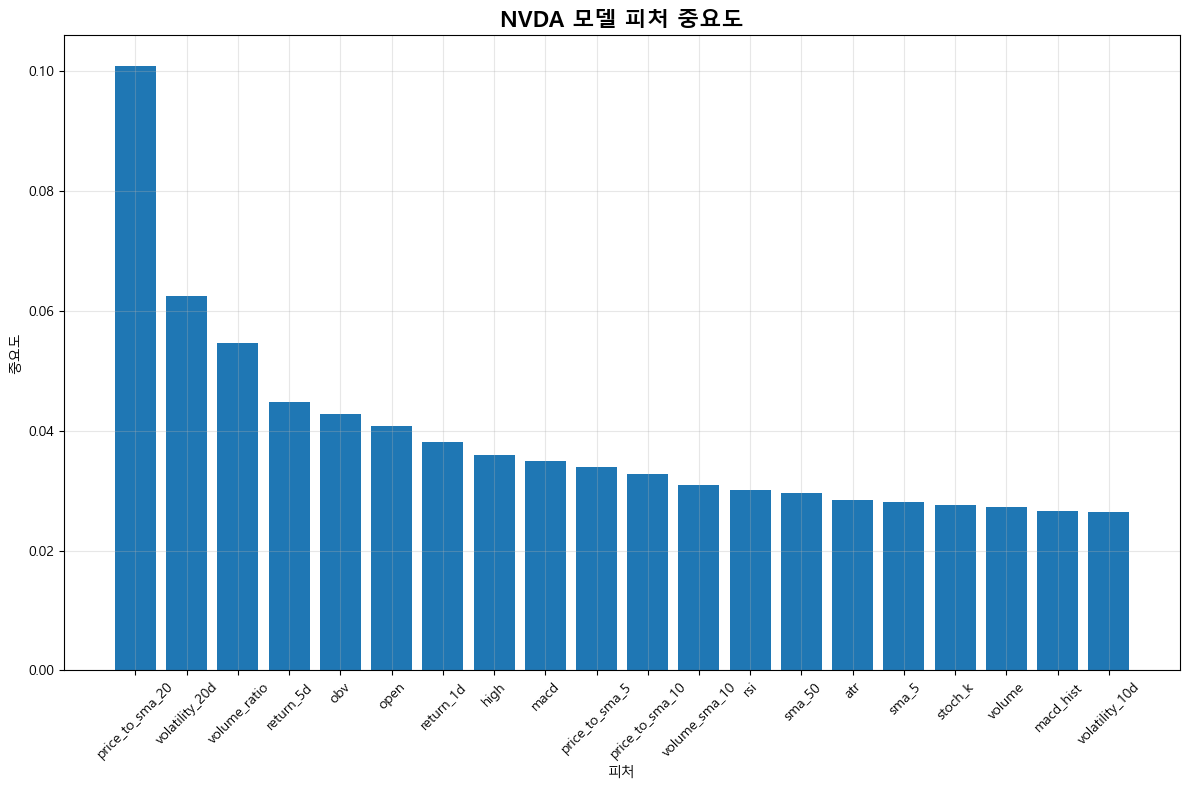

상위 10개 중요 피처:
 1. price_to_sma_20     : 0.1009
 2. volatility_20d      : 0.0625
 3. volume_ratio        : 0.0546
 4. return_5d           : 0.0447
 5. obv                 : 0.0428
 6. open                : 0.0408
 7. return_1d           : 0.0380
 8. high                : 0.0359
 9. macd                : 0.0349
10. price_to_sma_5      : 0.0340


In [67]:
# 2. 피처 중요도 분석
print("\n🔍 피처 중요도 분석")
print("-" * 40)
analyzer.feature_importance_plot()


In [68]:
# 고급 분석: 투자 의사결정 지원
class InvestmentDecisionSupport:
    def __init__(self, analyzer):
        self.analyzer = analyzer
        
    def generate_investment_recommendation(self):
        """투자 추천 생성"""
        metrics = self.analyzer.calculate_prediction_metrics()
        risk_metrics = self.analyzer.risk_analysis()
        
        current_price = metrics['현재가']
        predicted_avg = metrics['예측 평균가']
        expected_return = metrics['예상 총 수익률']
        upside_prob = metrics['상승 확률']
        volatility = risk_metrics['예측 변동성']
        var_95 = risk_metrics['VaR (95%)']
        
        # 투자 신호 계산
        signals = []
        score = 0
        
        # 수익률 기반 평가
        if expected_return > 5:
            signals.append("✅ 높은 수익률 기대 (+5% 이상)")
            score += 2
        elif expected_return > 2:
            signals.append("🟡 보통 수익률 기대 (2-5%)")
            score += 1
        else:
            signals.append("🔴 낮은 수익률 기대 (2% 미만)")
            score -= 1
        
        # 상승 확률 평가
        if upside_prob > 70:
            signals.append("✅ 높은 상승 확률 (70% 이상)")
            score += 2
        elif upside_prob > 50:
            signals.append("🟡 보통 상승 확률 (50-70%)")
            score += 1
        else:
            signals.append("🔴 낮은 상승 확률 (50% 미만)")
            score -= 1
        
        # 변동성 평가
        if volatility < 2:
            signals.append("✅ 낮은 변동성 (2% 미만)")
            score += 1
        elif volatility < 5:
            signals.append("🟡 보통 변동성 (2-5%)")
        else:
            signals.append("🔴 높은 변동성 (5% 이상)")
            score -= 1
        
        # VaR 평가
        if var_95 > -3:
            signals.append("✅ 낮은 리스크 (VaR -3% 이상)")
            score += 1
        elif var_95 > -5:
            signals.append("🟡 보통 리스크 (VaR -3% ~ -5%)")
        else:
            signals.append("🔴 높은 리스크 (VaR -5% 미만)")
            score -= 1
        
        # 최종 추천
        if score >= 4:
            recommendation = "🚀 강력 매수 추천"
            action = "BUY"
        elif score >= 2:
            recommendation = "📈 매수 추천"
            action = "BUY"
        elif score >= 0:
            recommendation = "⏸️ 관망 추천"
            action = "HOLD"
        else:
            recommendation = "📉 매도 고려"
            action = "SELL"
        
        return {
            'recommendation': recommendation,
            'action': action,
            'score': score,
            'signals': signals,
            'summary': {
                '현재가': f"${current_price:.2f}",
                '예측 평균가': f"${predicted_avg:.2f}",
                '기대 수익률': f"{expected_return:.2f}%",
                '상승 확률': f"{upside_prob:.1f}%",
                '리스크(VaR)': f"{var_95:.2f}%"
            }
        }
    
    def calculate_position_sizing(self, portfolio_value, risk_tolerance=0.02):
        """포지션 사이징 계산"""
        risk_metrics = self.analyzer.risk_analysis()
        var_95 = abs(risk_metrics['VaR (95%)']) / 100
        
        # Kelly Criterion 기반 포지션 사이징
        metrics = self.analyzer.calculate_prediction_metrics()
        expected_return = metrics['예상 총 수익률'] / 100
        win_prob = metrics['상승 확률'] / 100
        
        if var_95 > 0:
            kelly_fraction = (win_prob * expected_return - (1 - win_prob) * var_95) / var_95
            kelly_fraction = max(0, min(kelly_fraction, 0.25))  # 최대 25%로 제한
        else:
            kelly_fraction = 0
        
        # 리스크 조정 포지션
        risk_adjusted_position = portfolio_value * risk_tolerance / var_95 if var_95 > 0 else 0
        kelly_position = portfolio_value * kelly_fraction
        
        recommended_position = min(risk_adjusted_position, kelly_position)
        
        return {
            'Kelly_비율': f"{kelly_fraction:.2%}",
            'Kelly_포지션': f"${kelly_position:.2f}",
            '리스크조정_포지션': f"${risk_adjusted_position:.2f}",
            '추천_포지션': f"${recommended_position:.2f}",
            '주식수': int(recommended_position / metrics['현재가'])
        }
    
    def target_price_analysis(self):
        """목표가 분석"""
        metrics = self.analyzer.calculate_prediction_metrics()
        predictions = self.analyzer.predictions
        current_price = metrics['현재가']
        
        # 다양한 목표가 계산
        targets = {
            '보수적 목표가': np.percentile(predictions, 25),
            '중간 목표가': np.percentile(predictions, 50),
            '낙관적 목표가': np.percentile(predictions, 75),
            '최대 목표가': max(predictions)
        }
        
        target_analysis = {}
        for target_name, target_price in targets.items():
            return_pct = (target_price - current_price) / current_price * 100
            target_analysis[target_name] = {
                '목표가': f"${target_price:.2f}",
                '수익률': f"{return_pct:.2f}%",
                '달성확률': f"{sum(1 for p in predictions if p >= target_price) / len(predictions) * 100:.1f}%"
            }
        
        return target_analysis

# 투자 의사결정 지원 시스템 실행
decision_support = InvestmentDecisionSupport(analyzer)

print("\n💼 투자 의사결정 지원 분석")
print("=" * 50)

# 1. 투자 추천
print("\n🎯 투자 추천")
print("-" * 30)
recommendation = decision_support.generate_investment_recommendation()

print(f"최종 추천: {recommendation['recommendation']}")
print(f"액션: {recommendation['action']}")
print(f"신뢰도 점수: {recommendation['score']}/6")

print("\n📋 주요 지표:")
for key, value in recommendation['summary'].items():
    print(f"  {key}: {value}")

print("\n🔍 근거:")
for signal in recommendation['signals']:
    print(f"  {signal}")

print("\n" + "="*50)



💼 투자 의사결정 지원 분석

🎯 투자 추천
------------------------------
최종 추천: 📉 매도 고려
액션: SELL
신뢰도 점수: -4/6

📋 주요 지표:
  현재가: $177.82
  예측 평균가: $145.53
  기대 수익률: -14.99%
  상승 확률: 0.0%
  리스크(VaR): -16.62%

🔍 근거:
  🔴 낮은 수익률 기대 (2% 미만)
  🔴 낮은 상승 확률 (50% 미만)
  🔴 높은 변동성 (5% 이상)
  🔴 높은 리스크 (VaR -5% 미만)



In [69]:
# 2. 포지션 사이징 분석
print("\n💰 포지션 사이징 분석 (포트폴리오 $100,000 기준)")
print("-" * 50)
position_analysis = decision_support.calculate_position_sizing(100000, risk_tolerance=0.02)

for key, value in position_analysis.items():
    print(f"{key}: {value}")

# 3. 목표가 분석
print("\n🎯 목표가 분석")
print("-" * 30)
target_analysis = decision_support.target_price_analysis()

for target_name, info in target_analysis.items():
    print(f"\n{target_name}:")
    for metric, value in info.items():
        print(f"  {metric}: {value}")

print("\n" + "="*50)

# 4. 요약 및 결론
print("\n📝 분석 요약 및 투자 전략")
print("-" * 40)

current_price = analyzer.calculate_prediction_metrics()['현재가']
predicted_prices_str = ", ".join([f"${p:.2f}" for p in predicted_prices])

print(f"""
📌 NVDA 주식 분석 요약:

🔸 현재가: ${current_price:.2f}
🔸 5일 예측가: {predicted_prices_str}
🔸 투자 추천: {recommendation['recommendation']}
🔸 신뢰도: {recommendation['score']}/6점

💡 투자 전략 제안:
1. {recommendation['action']} 포지션 고려
2. 포트폴리오의 2% 리스크로 제한
3. 목표가는 보수적-낙관적 범위 설정
4. 지속적인 모니터링 필요

⚠️  주의사항:
- 이 분석은 과거 데이터 기반 예측입니다
- 실제 투자 전 추가적인 fundamental 분석 필요
- 리스크 관리를 최우선으로 고려하세요
- 분산투자를 통해 포트폴리오 리스크 관리
""")



💰 포지션 사이징 분석 (포트폴리오 $100,000 기준)
--------------------------------------------------
Kelly_비율: 0.00%
Kelly_포지션: $0.00
리스크조정_포지션: $12033.21
추천_포지션: $0.00
주식수: 0

🎯 목표가 분석
------------------------------

보수적 목표가:
  목표가: $142.72
  수익률: -19.74%
  달성확률: 80.0%

중간 목표가:
  목표가: $145.48
  수익률: -18.19%
  달성확률: 60.0%

낙관적 목표가:
  목표가: $148.29
  수익률: -16.61%
  달성확률: 40.0%

최대 목표가:
  목표가: $151.16
  수익률: -14.99%
  달성확률: 20.0%


📝 분석 요약 및 투자 전략
----------------------------------------

📌 NVDA 주식 분석 요약:

🔸 현재가: $177.82
🔸 5일 예측가: $140.02, $142.72, $145.48, $148.29, $151.16
🔸 투자 추천: 📉 매도 고려
🔸 신뢰도: -4/6점

💡 투자 전략 제안:
1. SELL 포지션 고려
2. 포트폴리오의 2% 리스크로 제한
3. 목표가는 보수적-낙관적 범위 설정
4. 지속적인 모니터링 필요

⚠️  주의사항:
- 이 분석은 과거 데이터 기반 예측입니다
- 실제 투자 전 추가적인 fundamental 분석 필요
- 리스크 관리를 최우선으로 고려하세요
- 분산투자를 통해 포트폴리오 리스크 관리



# ㅇㅇ